In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm
import tensorflow as tf
from datetime import datetime
from sklearn.decomposition import PCA
pd.set_option('display.max_rows', None)

In [2]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
val = pd.read_csv('data/val.csv')

In [3]:
list(train.columns)

['Attack code_x',
 'Avg source IP count',
 'Detect count_y',
 'Victim IP_y',
 'Port number_y',
 'Packet speed_y',
 'Data speed_y',
 'Avg packet len_y',
 'Source IP count',
 'Packet speed_y_normalized',
 'Data speed_y_normalized',
 'Avg packet len_y_normalized',
 'total_seconds',
 'weekday_number',
 'IsWeekend',
 'Start Hour',
 'Sin_Hour',
 'Cos_Hour',
 'DayOfYear',
 'Sin_DayOfYear',
 'Cos_DayOfYear',
 'Mean_DataSpeed',
 'Std_DataSpeed',
 'Min_DataSpeed',
 'Max_DataSpeed',
 'Mean_DetectCount',
 'Std_DetectCount',
 'Min_DetectCount',
 'Max_DetectCount',
 'VictimIP_Count',
 'PortNumber_Count',
 'AvgPacketLen_Mean',
 'AvgPacketLen_Std',
 'DataSpeed_PacketSpeed',
 'PortFrequency',
 'Std_DataSpeed_Replaced',
 'Std_DetectCount_Replaced',
 'AvgPacketLen_Std_Replaced',
 'packet_Total',
 'PacketSpeed_Per_Second',
 'DataSpeed_Per_TotalSeconds',
 'AvgPacketLen_Per_TotalSeconds',
 'PCA_1',
 'PCA_2',
 'PCA_3',
 'PCA_4',
 'PCA_5',
 'Is_HTTP',
 'Is_HTTPS',
 'Is_FTP_Control',
 'Is_FTP_Data',
 'Is_SSH',

In [4]:
x_cols = ['Avg source IP count', 'Detect count_y', 'Victim IP_y', 'Port number_y', 'Packet speed_y',
       'Data speed_y', 'Avg packet len_y', 'Source IP count',
       'Packet speed_y_normalized', 'Data speed_y_normalized',
       'Avg packet len_y_normalized', 'total_seconds', 'weekday_number',
       'IsWeekend', 'Start Hour', 'Sin_Hour', 'Cos_Hour', 'DayOfYear',
       'Sin_DayOfYear', 'Cos_DayOfYear', 'Mean_DataSpeed', 'Std_DataSpeed',
       'Min_DataSpeed', 'Max_DataSpeed', 'Mean_DetectCount', 'Std_DetectCount',
       'Min_DetectCount', 'Max_DetectCount', 'VictimIP_Count',
       'PortNumber_Count', 'AvgPacketLen_Mean', 'AvgPacketLen_Std',
       'DataSpeed_PacketSpeed', 'PortFrequency', 'Std_DataSpeed_Replaced',
       'Std_DetectCount_Replaced', 'AvgPacketLen_Std_Replaced', 'packet_Total',
       'PacketSpeed_Per_Second', 'DataSpeed_Per_TotalSeconds',
       'AvgPacketLen_Per_TotalSeconds', 'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4',
       'PCA_5', 'Is_HTTP', 'Is_HTTPS', 'Is_FTP_Control','Is_FTP_Data','Is_SSH',
       'Is_Telnet','Is_SMTP','Is_DNS','Is_POP3','Is_IMAP','Is_DHCP','Is_SNMP',
       'Is_LDAP','Is_LDAPS','Is_SMB_CIFS','Is_RDP','Is_SIP','Is_TFTP','Is_MySQL',
       'Is_PostgreSQL','Is_Oracle','Is_HTTP_Alt_8080','Is_HTTP_Alt_8081',
       'Is_HTTP_Alt_80','Is_HTTPS_Alt_8443','Is_Syslog','Is_VNC','Is_IRC', 
       'Is_NTP','Is_Kerberos','Is_LDAP_Alt','Is_LDAPS_Alt','Is_RADIUS',
       'Is_PPTP','Is_RTSP','Is_X11','Is_SNMP_Trap','Is_BGP','Is_IMAPS_Alt',
       'Is_POP3S_Alt','Is_Telnet_SSL','Is_NNTP','Is_NNTPS','Is_LDAP_TLS',
       'Is_AFS','Is_NFS','Is_SOCKS','Is_RSYNC','Is_CUPS','Is_TFTP_Alt',
       'Is_Modbus','Is_CoAP','Is_MQTT','Is_AMQP','Is_Redis','Is_Memcached',
       'Is_Elasticsearch','Is_Zookeeper','Is_Cassandra','Is_Docker',
       'Is_Kubernetes','Is_SMB_Direct','Is_iSCSI','Is_AFP','Is_DHCPv6',
       'Is_RIPng','Is_OSPF','Is_PPPoE','Is_L2TP', 'Is_GRE','Is_ESP','Is_AH']

In [18]:
# Import necessary libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Initialize the Random Forest classifier
rfc = RandomForestClassifier(n_estimators=250, random_state=42, max_depth=10, verbose=1)

# Train the classifier on the training data
rfc.fit(train[x_cols], train['Attack code_x'])

# Predict the labels for the test data
test['pred'] = rfc.predict(test[x_cols])

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  3.9min
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed: 15.8min
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   23.3s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:  1.6min


In [19]:
accuracy = accuracy_score(test['Attack code_x'], test['pred'])
print("Accuracy:", accuracy)
precision = precision_score(test['Attack code_x'], test['pred'], average='macro')
print("Precision:", precision)
recall = recall_score(test['Attack code_x'], test['pred'], average='macro')
print("Recall:", recall)
f1 = f1_score(test['Attack code_x'], test['pred'], average='macro')
print("F1-Score:", f1)

Accuracy: 2.2449100672991968e-05
Precision: 0.008631726000772805


c:\Users\Admin\anaconda3\envs\DS\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Admin\anaconda3\envs\DS\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Recall: 0.013280861812073563
F1-Score: 0.0011945600214774805


In [5]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


def objective(trial):
    # Define the hyperparameters to optimize and their search spaces
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    max_depth = trial.suggest_int('max_depth', 2, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5)

    # Create the Random Forest Classifier with the suggested hyperparameters
    rfc = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )

    # Train the model
    rfc.fit(train[x_cols], train['Attack code_x'])

    # Make predictions on the test set
    y_pred = rfc.predict(test[x_cols])

    # Calculate the evaluation metric (accuracy in this case)
    accuracy = accuracy_score(test['Attack code_x'], y_pred)
    return accuracy

if __name__ == "__main__":
    # Create a study object and specify the optimization direction
    study = optuna.create_study(direction='maximize')

    # Run the optimization process
    study.optimize(objective, n_trials=10)  # Number of trials to run

    # Print the best hyperparameters found
    print("Best hyperparameters:", study.best_params)

    # Get the best score achieved
    print("Best accuracy:", study.best_value)

    # Create a model with the best hyperparameters
    best_rfc = RandomForestClassifier(**study.best_params, random_state=42)

    # Train the best model on the full training data
    best_rfc.fit(train[x_cols], train['Attack code_x'])

    # Evaluate the best model on the test setí
    y_pred_best = best_rfc.predict(test[x_cols])
    best_accuracy = accuracy_score(test['Attack code_x'], y_pred_best)
    print(f"Accuracy of the best model on the test set: {best_accuracy:.4f}")

    # You can also visualize the optimization history and parameter importance
    optuna.visualization.plot_optimization_history(study).show()
    optuna.visualization.plot_param_importances(study).show()

[I 2025-05-08 19:36:51,369] A new study created in memory with name: no-name-dd5f0c1f-fe1c-4a9d-95e3-c5798f309018
[I 2025-05-08 20:09:55,053] Trial 0 finished with value: 0.00010743498179217585 and parameters: {'n_estimators': 414, 'max_depth': 9, 'min_samples_split': 6, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.00010743498179217585.
[I 2025-05-08 20:19:12,169] Trial 1 finished with value: 0.00015313493673362378 and parameters: {'n_estimators': 69, 'max_depth': 19, 'min_samples_split': 5, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.00015313493673362378.
[I 2025-05-08 20:26:52,389] Trial 2 finished with value: 7.215782359175989e-06 and parameters: {'n_estimators': 179, 'max_depth': 4, 'min_samples_split': 7, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.00015313493673362378.
[I 2025-05-08 21:30:47,223] Trial 3 finished with value: 0.00017638579100207974 and parameters: {'n_estimators': 381, 'max_depth': 33, 'min_samples_split': 7, 'min_samples_leaf': 3}. Be

Best hyperparameters: {'n_estimators': 240, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 3}
Best accuracy: 0.00046982760694190334
Accuracy of the best model on the test set: 0.0005


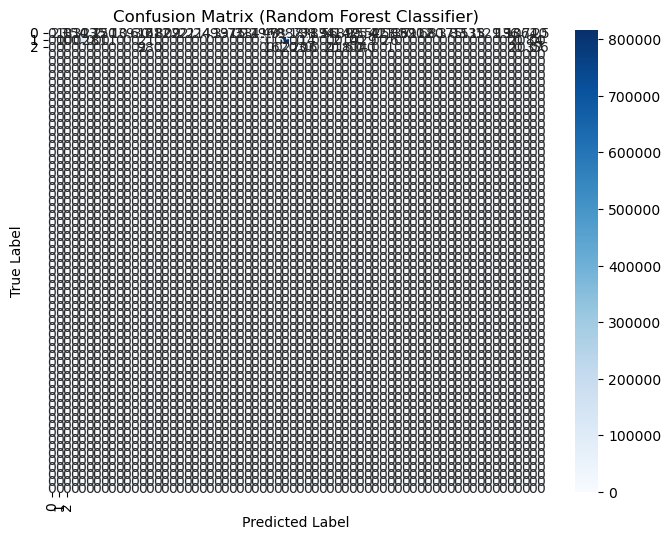

Confusion Matrix (Random Forest Classifier):
 [[    0    23     0 ... 13640     1    25]
 [    0     0     0 ...  2084     0     0]
 [    0     0     0 ...  2037     0    56]
 ...
 [    0     0     0 ...     0     0     0]
 [    0     0     0 ...     0     0     0]
 [    0     0     0 ...     0     0     0]]


In [6]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


# 1. Generate the confusion matrix
cm = confusion_matrix(test['Type'], y_pred_best)

# 2. Visualize the confusion matrix (optional, but highly recommended)
class_labels = np.unique(test['Type']) # Get unique class labels

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Random Forest Classifier)')
plt.show()

# 3. Print the confusion matrix (textual representation)
print("Confusion Matrix (Random Forest Classifier):\n", cm)

In [7]:
from sklearn.metrics import classification_report
import numpy as np

# Generate the classification report
report = classification_report(y_pred_best, test['Type'])

# Print the classification report
print("Classification Report (Random Forest Classifier):\n", report)

c:\Users\Admin\anaconda3\envs\DS\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\Admin\anaconda3\envs\DS\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning:

Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.



Classification Report (Random Forest Classifier):
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00      23.0
           2       0.00      0.00      0.00       0.0
           4       0.00      0.00      0.00     154.0
           8       0.00      0.00      0.00  233553.0
          14       0.00      0.00      0.00    1035.0
          15       0.00      0.00      0.00       2.0
          18       0.00      0.00      0.00     151.0
          22       0.00      0.00      0.00       1.0
          23       0.00      0.00      0.00      10.0
          24       0.00      0.00      0.00      39.0
          25       0.00      0.00      0.00       6.0
          27       0.00      0.00      0.00      34.0
          29       0.00      0.00      0.00    1149.0
          31       0.00      0.00      0.00     212.0
          35       0.00      0.00      0.00    1802.0
          36       0.00      0

c:\Users\Admin\anaconda3\envs\DS\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\Admin\anaconda3\envs\DS\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning:

Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.

c:\Users\Admin\anaconda3\envs\DS\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\Admin\anaconda3\envs\DS\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning:

Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this